TÉCNICA DE ENSEMBLE BOOST REGRESSION (CON DATOS PREPROCESADOS)

In [ ]:
import os
import numpy as np

root_dir = r"../Spectra/FinalSamples/Level2"
dir_wln = os.path.join(root_dir, f"LVL2_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"LVL2_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")

In [2]:
import pandas as pd
#Leer archivo de concentraciones
root_dir_concentraciones = r"../Spectra/FinalSamples"
dir_concentraciones = os.path.join(root_dir_concentraciones, f"concentraciones.txt")
concentraciones = pd.read_csv(dir_concentraciones, sep='\t')


In [3]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

x = np.array(all_Spectra).T # Espectros de LIBS preprocesados
ys = concentraciones["Sulfato_de_Sodio"].values
y = np.array(ys) # Concentraciones de sulfato de sodio

print("Dimensión de x (espectros):", x.shape)
print("Dimensión de y (concentraciones):", y.shape)



Dimensión de x (espectros): (75, 7283)
Dimensión de y (concentraciones): (75,)


In [4]:
# División de los datos en entrenamiento y prueba

x_train, x_test, y_train, y_test = train_test_split(x,y, test_size = 0.2, random_state=17)

In [5]:
# Crear y entrenar el modelo

model = GradientBoostingRegressor(n_estimators=600, learning_rate=0.01, max_depth=3, max_features='log2', min_samples_leaf=5, min_samples_split=3, subsample=0.8, random_state=67)

model.fit(x_train, y_train)


GradientBoostingRegressor(learning_rate=0.01, max_features='log2',
                          min_samples_leaf=5, min_samples_split=3,
                          n_estimators=600, random_state=67, subsample=0.8)

In [6]:
y_pred = model.predict(x_test)
y_pred_train = model.predict(x_train)

24.755382540004575
[49.33 90.5  20.95 75.88 14.4  98.31 96.92 96.92 38.76  7.36 38.76  6.29
  6.29 93.63 33.15]
[49.93902227 84.19059507 26.65913594 84.44853279 17.5259701  97.08242327
 95.51310067 93.69940446 44.98523014  8.0064286  48.03671039 13.03279243
  9.20685348 88.92230962 32.77228547]


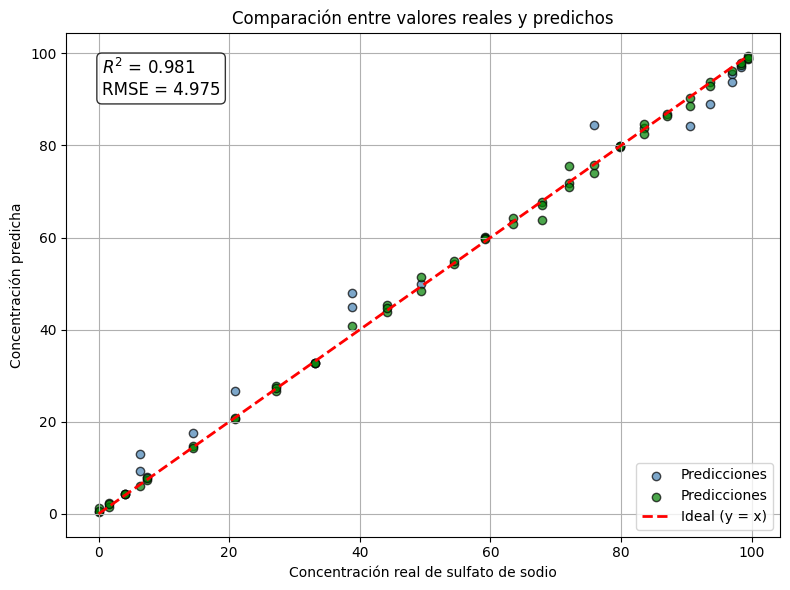

In [7]:
mse = mean_squared_error(y_test, y_pred)
print(mse)
print(y_test)
print(y_pred)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train, y_pred_train, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train), max(y_train)], [min(y_train), max(y_train)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de sodio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


Dimensión original: (75, 7283)
Dimensión reducida: (75, 500)
28.660430855713177
[49.33 90.5  20.95 75.88 14.4  98.31 96.92 96.92 38.76  7.36 38.76  6.29
  6.29 93.63 33.15]
[52.05115535 87.72341129 29.72792693 85.70461692 20.37629571 98.51288898
 97.78640025 96.01861015 45.44252416  8.25773814 48.14696937 14.28219886
  5.63881765 96.0350479  33.63581047]


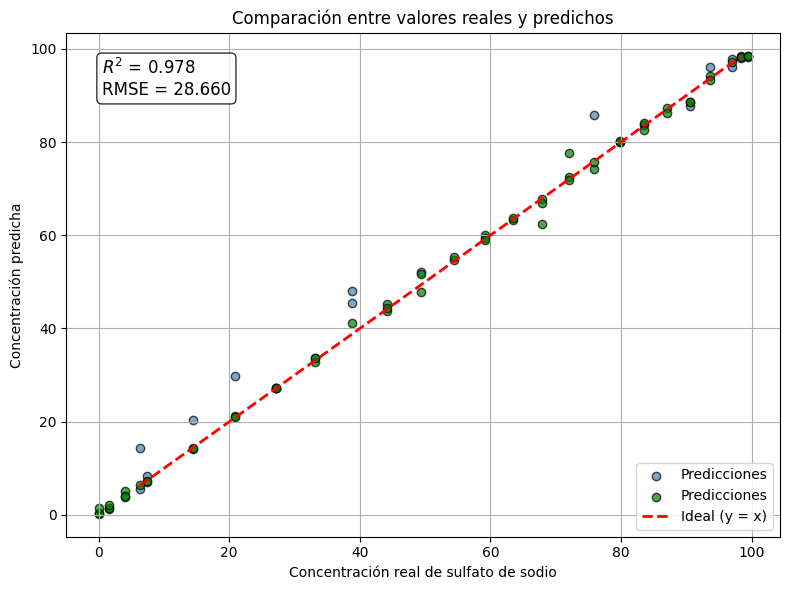

In [ ]:
#Intento de mejora mediante selección de características. NO PARECE QUE MEJORE.
'''
from sklearn.feature_selection import SelectKBest, f_regression

# Selección de características
selector = SelectKBest(score_func=f_regression, k=500)  # por ejemplo, las 500 más relevantes
x_reducido = selector.fit_transform(x, y)

# Verificación
print("Dimensión original:", x.shape)
print("Dimensión reducida:", x_reducido.shape)

x_train2, x_test2, y_train2, y_test2 = train_test_split(x_reducido,y, test_size = 0.2, random_state=17)

model2 = GradientBoostingRegressor(n_estimators=600, learning_rate=0.01, max_depth=3, max_features='log2', min_samples_leaf=5, min_samples_split=3, subsample=0.8, random_state=67)

model2.fit(x_train2, y_train2)

y_pred2 = model2.predict(x_test2)
y_pred_train2 = model2.predict(x_train2)

mse = mean_squared_error(y_test2, y_pred2)
print(mse)
print(y_test2)
print(y_pred2)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = mean_squared_error(y_test2, y_pred2)
r2 = r2_score(y_test2, y_pred2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test2, y_pred2, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train2, y_pred_train2, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_test2), max(y_test2)], [min(y_test2), max(y_test2)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de sodio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()
'''

In [8]:
ys2 = concentraciones["Sulfato_de_Magnesio"].values
y2 = np.array(ys2) # Concentraciones de sulfato de sodio
x_train2, x_test2, y_train2, y_test2 = train_test_split(x,y2, test_size = 0.2, random_state=16)
model2 = GradientBoostingRegressor(n_estimators=600, learning_rate=0.01, max_depth=3, max_features='log2', min_samples_leaf=5, min_samples_split=3, subsample=0.8, random_state=67)

model2.fit(x_train2, y_train2)
y_pred2 = model2.predict(x_test2)
y_pred_train2 = model2.predict(x_train2)


56.82916689104469
[ 61.24 100.    98.34  36.49  20.21  24.12  27.99  13.04   0.63  20.21
   9.5   96.02  79.05  16.45  72.84]
[48.78432013 92.61851802 94.84216089 30.19979885 18.71540185 12.5809916
 11.30052962 19.59662866  2.37367075 21.31639804 11.43519123 87.10187127
 85.10145224 14.39582382 70.44976694]


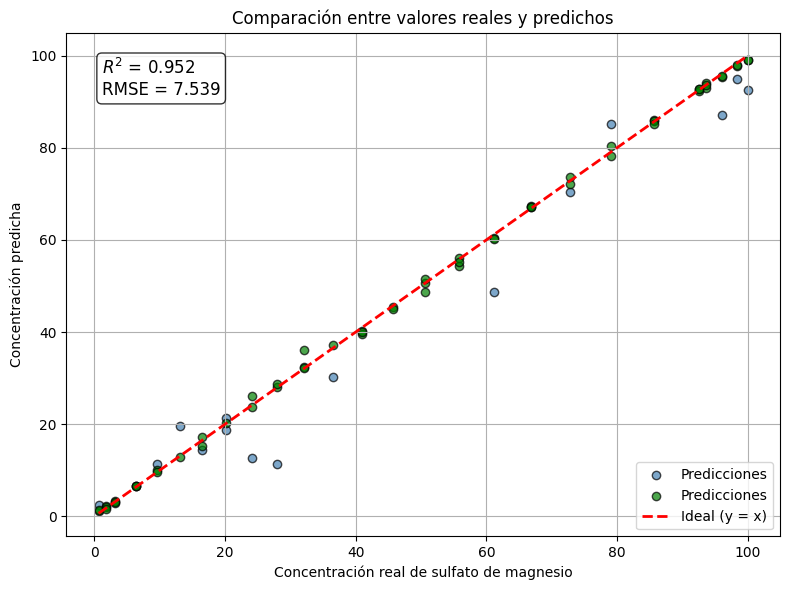

In [10]:
mse = mean_squared_error(y_test2, y_pred2)
print(mse)
print(y_test2)
print(y_pred2)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test2, y_pred2)

plt.figure(figsize=(8, 6))
plt.scatter(y_test2, y_pred2, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train2, y_pred_train2, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train2), max(y_train2)], [min(y_train2), max(y_train2)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de magnesio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


TÉCNICA DE ENSEMBLE BOOST REGRESSION (CON DATOS SIN PREPROCESAR)

In [11]:
# Ruta donde están los archivos LVL2_MX_PY.txt
root_dir = r"../Spectra/FinalSamples/Level1"

# Se guardarán aquí:
wavelengths = None            # array 1D con las longitudes de onda del primer archivo válido
intensity_cols = []           # lista de arrays 1D con las intensidades de cada archivo
filenames = []                # lista de nombres de archivos cargados, en orden

In [13]:
# Recorremos MX=1..27 y PY=1..3 en orden numérico
for mx in range(1, 28):
    for py in range(1, 4):
        fname = f"LVL1_M{mx}_P{py}.txt"
        fpath = os.path.join(root_dir, fname)
        try:
            # Cargar dos columnas: wave, intensity
            data = np.loadtxt(fpath, delimiter=',')
            wave = data[:, 0]
            spec = data[:, 1]
            
            # Si es el primer archivo válido, guardamos las longitudes
            if wavelengths is None:
                wavelengths = wave.copy()
            else:
                # Chequeo rápido: que coincidan los ejes
                if not np.allclose(wavelengths, wave):
                    raise ValueError(f"El eje de longitudes no coincide en {fname}")
            
            # Añadimos la columna de intensidades y el nombre
            intensity_cols.append(spec)
            filenames.append(fname)
        except Exception:
            # No existe el archivo o hay error: lo ignoramos
            continue
# Ahora componemos la matriz (N, k)
if intensity_cols:
    intensity_matrix = np.column_stack(intensity_cols)  # shape (N, k)
else:
    intensity_matrix = np.empty((0, 0))

In [14]:
# Mostramos resultados
# intensity_matrix: shape (N, k)
# filenames: list of length k, e.g. ['LVL1_1_1.txt', 'LVL1_1_2.txt', …]
print("Archivos cargados en orden:")
print(filenames)
print(f"\nLongitudes de onda (N={wavelengths.size if wavelengths is not None else 0}):")
print(wavelengths)
print(f"\nMatriz de intensidades (shape={intensity_matrix.shape}):")
print(intensity_matrix)

Archivos cargados en orden:
['LVL1_M1_P1.txt', 'LVL1_M1_P2.txt', 'LVL1_M1_P3.txt', 'LVL1_M2_P1.txt', 'LVL1_M2_P2.txt', 'LVL1_M2_P3.txt', 'LVL1_M3_P1.txt', 'LVL1_M3_P2.txt', 'LVL1_M3_P3.txt', 'LVL1_M4_P1.txt', 'LVL1_M4_P2.txt', 'LVL1_M4_P3.txt', 'LVL1_M5_P1.txt', 'LVL1_M5_P2.txt', 'LVL1_M5_P3.txt', 'LVL1_M6_P1.txt', 'LVL1_M6_P2.txt', 'LVL1_M6_P3.txt', 'LVL1_M7_P1.txt', 'LVL1_M7_P2.txt', 'LVL1_M7_P3.txt', 'LVL1_M8_P1.txt', 'LVL1_M8_P2.txt', 'LVL1_M8_P3.txt', 'LVL1_M9_P1.txt', 'LVL1_M9_P2.txt', 'LVL1_M9_P3.txt', 'LVL1_M10_P1.txt', 'LVL1_M10_P2.txt', 'LVL1_M10_P3.txt', 'LVL1_M11_P1.txt', 'LVL1_M11_P2.txt', 'LVL1_M11_P3.txt', 'LVL1_M12_P1.txt', 'LVL1_M12_P2.txt', 'LVL1_M12_P3.txt', 'LVL1_M13_P2.txt', 'LVL1_M13_P3.txt', 'LVL1_M14_P1.txt', 'LVL1_M14_P2.txt', 'LVL1_M14_P3.txt', 'LVL1_M15_P2.txt', 'LVL1_M15_P3.txt', 'LVL1_M16_P1.txt', 'LVL1_M16_P2.txt', 'LVL1_M16_P3.txt', 'LVL1_M17_P1.txt', 'LVL1_M17_P2.txt', 'LVL1_M17_P3.txt', 'LVL1_M18_P1.txt', 'LVL1_M18_P2.txt', 'LVL1_M18_P3.txt', 'LVL1_M19_

In [15]:
out_wln = os.path.join(root_dir, f"LVL1_Wavelengths.txt")
out_spec = os.path.join(root_dir, f"LVL1_All_Spectra.txt")

# Write a header line with the original file‑names, tab‑delimited
header = "\t".join(filenames)


# Save the Spectra matrix
np.savetxt(out_spec,intensity_matrix,
    fmt="%.6e",        # scientific notation, 6 decimals
    delimiter="\t",
    header=header,
    comments=""         # don’t prefix the header with “#”
)

# Save the Wavelengths matrix
np.savetxt(out_wln,wavelengths,
    fmt="%.6e",        # scientific notation, 6 decimals
    delimiter="\t",
    comments=""         # don’t prefix the header with “#”
)

Leer los archivos

In [17]:
root_dir = r"../Spectra/FinalSamples/Level1"
dir_wln = os.path.join(root_dir, f"LVL1_Wavelengths.txt")
dir_spec = os.path.join(root_dir, f"LVL1_All_Spectra.txt")
with open(dir_spec, "r") as f:
    first_line = f.readline().strip()
column_names = first_line.split("\t")
all_Spectra_non_processed = np.genfromtxt(dir_spec, skip_header=1)   
# data is shape (N, Files)
# to recover column M1_P1:
#spec_m1_p1 = all_Spectra[:, j]
wavelengths = np.loadtxt(dir_wln, delimiter="\t")


In [19]:
x3 = np.array(all_Spectra_non_processed).T # Espectros de LIBS preprocesados
ys3 = concentraciones["Sulfato_de_Sodio"].values
y3 = np.array(ys3) # Concentraciones de sulfato de sodio

In [21]:
x_train3, x_test3, y_train3, y_test3 = train_test_split(x3,y3, test_size = 0.2, random_state=17)
model3 = GradientBoostingRegressor(n_estimators=600, learning_rate=0.01, max_depth=3, max_features='log2', min_samples_leaf=5, min_samples_split=3, subsample=0.8, random_state=67)
model3.fit(x_train3, y_train3)

y_pred3 = model3.predict(x_test3)
y_pred_train3 = model3.predict(x_train3)

124.30271537570208
[49.33 90.5  20.95 75.88 14.4  98.31 96.92 96.92 38.76  7.36 38.76  6.29
  6.29 93.63 33.15]
[39.8334691  82.51437133 18.71923795 71.26934061 15.8554756  93.71522665
 92.85627085 92.13653814 48.53118353 29.43531322 52.57133977 14.43883546
  3.20705528 65.85167943 33.94648251]


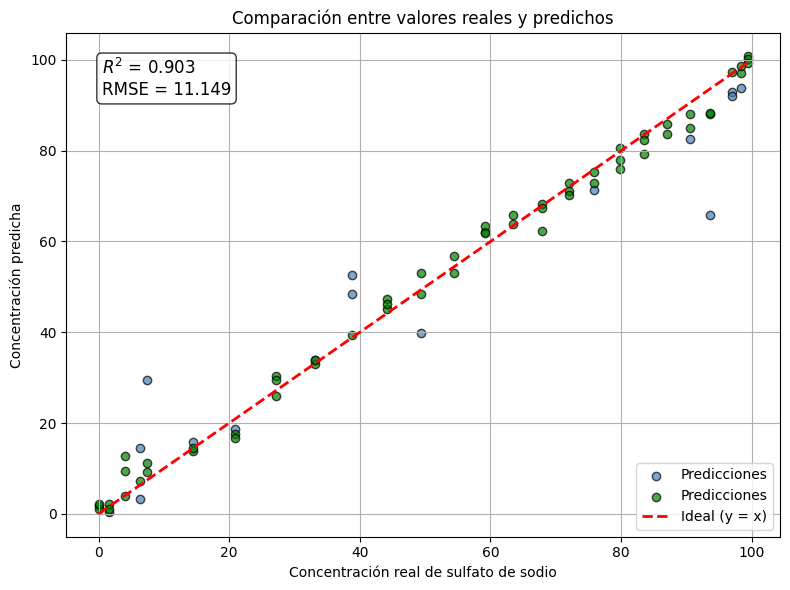

In [22]:
mse = mean_squared_error(y_test3, y_pred3)
print(mse)
print(y_test3)
print(y_pred3)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test3, y_pred3)

plt.figure(figsize=(8, 6))
plt.scatter(y_test3, y_pred3, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train3, y_pred_train3, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train3), max(y_train3)], [min(y_train3), max(y_train3)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de sodio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


125.99880942933103
[50.67  9.5  79.05 24.12 85.6   1.69  3.08  3.08 61.24 92.64 61.24 93.71
 93.71  6.37 66.85]
[60.26104905 17.35270604 81.46821655 28.78158817 84.0643875   6.173332
  7.09760157  7.94261449 51.17492589 70.18227056 47.43712605 85.72339634
 96.45004654 34.26919361 66.02970524]


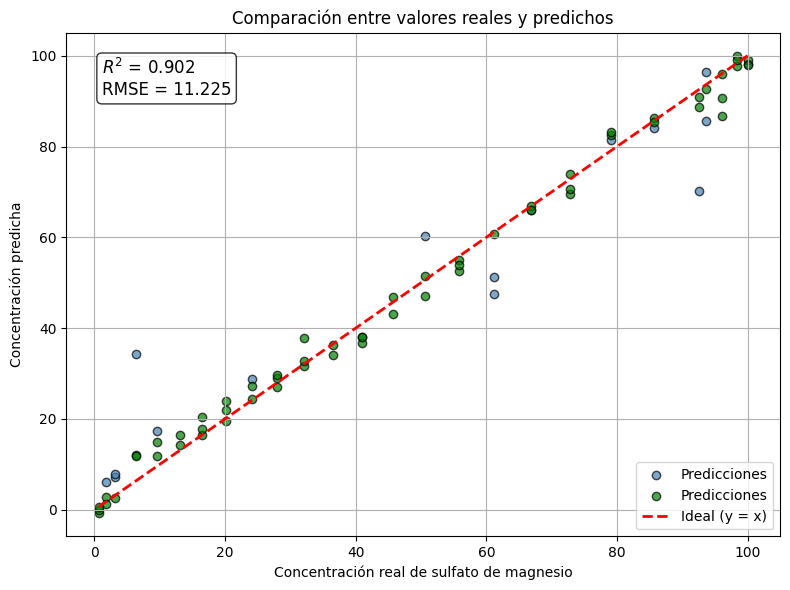

In [25]:
ys4 = concentraciones["Sulfato_de_Magnesio"].values
y4 = np.array(ys4)

x_train4, x_test4, y_train4, y_test4 = train_test_split( x3 ,y4, test_size = 0.2, random_state=17)
model4 = GradientBoostingRegressor(n_estimators=600, learning_rate=0.01, max_depth=3, max_features='log2', min_samples_leaf=5, min_samples_split=3, subsample=0.8, random_state=67)
model4.fit(x_train4, y_train4)

y_pred4 = model4.predict(x_test4)
y_pred_train4 = model4.predict(x_train4)

mse = mean_squared_error(y_test4, y_pred4)
print(mse)
print(y_test4)
print(y_pred4)

import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

# Suponiendo que ya tienes y_test e y_pred
rmse = np.sqrt(mse)
r2 = r2_score(y_test4, y_pred4)

plt.figure(figsize=(8, 6))
plt.scatter(y_test4, y_pred4, color='steelblue', edgecolors='k', alpha=0.7, label='Predicciones')
plt.scatter(y_train4, y_pred_train4, color='green', edgecolors='k', alpha=0.7, label='Predicciones')
plt.plot([min(y_train4), max(y_train4)], [min(y_train4), max(y_train4)], 'r--', lw=2, label='Ideal (y = x)')
plt.xlabel('Concentración real de sulfato de magnesio')
plt.ylabel('Concentración predicha')
plt.title('Comparación entre valores reales y predichos')

# Añadir métricas al gráfico
plt.text(0.05, 0.95,
         f'$R^2$ = {r2:.3f}\nRMSE = {rmse:.3f}',
         transform=plt.gca().transAxes,
         fontsize=12,
         verticalalignment='top',
         bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))

plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()